In [1]:
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

In [2]:
X, y = load_iris(return_X_y=True)

In [3]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

In [4]:
sc = StandardScaler()
X_tr = sc.fit_transform(X_tr)
X_te = sc.transform(X_te)

In [16]:
rates = [0.0001, 0.001, 0.01, 0.1, 1.0]

losses = []
accuracies = []

for lr in rates:
    mlp = MLPClassifier(
        hidden_layer_sizes=(32,),
        learning_rate_init=lr,
        max_iter=200,
        random_state=42
    )

    mlp.fit(X_tr, y_tr)

    losses.append(mlp.loss_curve_[-1])
    accuracies.append(mlp.score(X_te, y_te))

E:\AI-ML\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
E:\AI-ML\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
E:\AI-ML\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


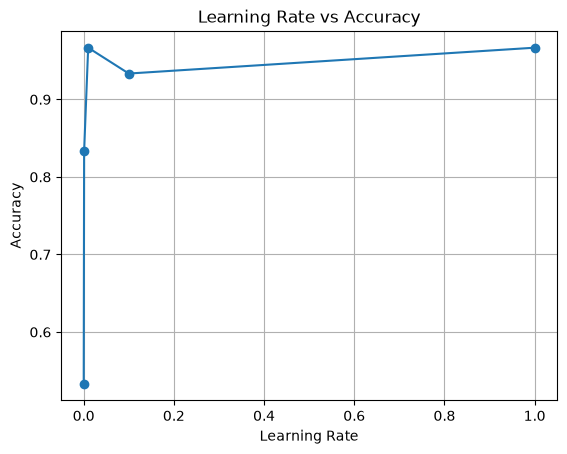

In [17]:
plt.plot(rates, accuracies, marker="o")
plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")
plt.title("Learning Rate vs Accuracy")
plt.grid(True)
plt.show()

E:\AI-ML\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
E:\AI-ML\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


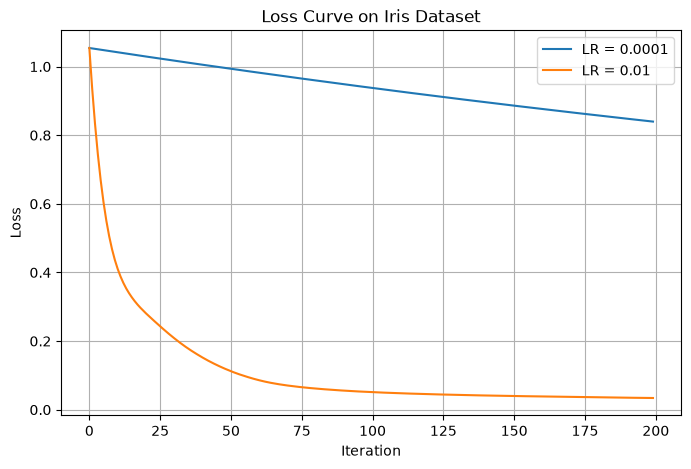

In [11]:
small = MLPClassifier(
    hidden_layer_sizes=(32,),
    learning_rate_init=0.0001,
    max_iter=200,
    random_state=42
)

good = MLPClassifier(
    hidden_layer_sizes=(32,),
    learning_rate_init=0.01,
    max_iter=200,
    random_state=42
)

small.fit(X_tr, y_tr)
good.fit(X_tr, y_tr)


plt.figure(figsize=(8,5))
plt.plot(small.loss_curve_, label="LR = 0.0001")
plt.plot(good.loss_curve_, label="LR = 0.01")

plt.title("Loss Curve on Iris Dataset")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()